In [52]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [53]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"
EXPORT_DIR = "/content/drive/MyDrive/HW4_MLOps_Export/"

os.makedirs(EXPORT_DIR, exist_ok=True)
print("Export folder ready:", EXPORT_DIR)

Export folder ready: /content/drive/MyDrive/HW4_MLOps_Export/


In [55]:
files = {
    "orders_df": "olist_orders_dataset.csv.zip",
    "order_items_df": "olist_order_items_dataset.csv.zip",
    "order_payments_df": "olist_order_payments_dataset.csv.zip",
    "order_reviews_df": "olist_order_reviews_dataset.csv.zip",
    "customers_df": "olist_customers_dataset.csv.zip",
    "products_df": "olist_products_dataset.csv.zip",
    "sellers_df": "olist_sellers_dataset.csv",
    "category_translation_df": "product_category_name_translation.csv"
}

def load_any_csv(path):
    if path.endswith(".zip"):
        return pd.read_csv(path, compression="zip")
    return pd.read_csv(path)

tables = {name: load_any_csv(DATA_DIR + fname) for name, fname in files.items()}

orders_df = tables["orders_df"]
order_items_df = tables["order_items_df"]
order_payments_df = tables["order_payments_df"]
order_reviews_df = tables["order_reviews_df"]
customers_df = tables["customers_df"]
products_df = tables["products_df"]
sellers_df = tables["sellers_df"]
category_translation_df = tables["category_translation_df"]

print("All tables loaded successfully.")

All tables loaded successfully.


In [56]:
# Base dataset: orders + reviews
df = orders_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

df = df[df["review_score"].notna()].copy()
df["is_positive_review"] = (df["review_score"] >= 4).astype(int)

# Product categories translated to English
products_en = products_df.copy()

if "product_category" not in products_en.columns:
    products_en = products_en.merge(
        category_translation_df,
        on="product_category_name",
        how="left"
    )
    products_en = products_en.rename(
        columns={"product_category_name_english": "product_category"}
    )

# Order-level item aggregates
order_items_agg = (
    order_items_df.groupby("order_id")
    .agg(
        price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

# Payment aggregates
payments_agg = (
    order_payments_df.groupby("order_id")
    .agg(
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

# Merge
df = df.merge(order_items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")

df = df.merge(
    products_en[["product_id", "product_category"]],
    on="product_id",
    how="left"
)

df = df.merge(
    sellers_df[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

# Datetime features
orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"], errors="coerce"
)
orders_df["order_delivered_customer_date"] = pd.to_datetime(
    orders_df["order_delivered_customer_date"], errors="coerce"
)
orders_df["order_estimated_delivery_date"] = pd.to_datetime(
    orders_df["order_estimated_delivery_date"], errors="coerce"
)

date_cols = orders_df[[
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].copy()

df = df.merge(date_cols, on="order_id", how="left")

df["delivery_days"] = (
    df["order_delivered_customer_date_y"] - df["order_purchase_timestamp_y"]
).dt.days

df["delivery_vs_estimated"] = (
    df["order_delivered_customer_date_y"] - df["order_estimated_delivery_date_y"]
).dt.days

feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "price",
    "freight_value",
    "product_category",
    "seller_state",
    "payment_type"
]

target_col = "is_positive_review"

df_model = df[feature_cols + [target_col]].copy()
df_model = df_model.dropna().copy()

print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (94981, 8)


,delivery_days,delivery_vs_estimated,price,freight_value,product_category,seller_state,payment_type,is_positive_review
0,8.0,-8.0,29.99,8.72,housewares,SP,credit_card,1
1,13.0,-6.0,118.70,22.76,perfumery,SP,boleto,1
2,9.0,-18.0,159.90,19.22,auto,SP,credit_card,1
3,13.0,-13.0,45.00,27.20,pet_shop,MG,credit_card,1
4,2.0,-10.0,19.90,8.72,stationery,SP,credit_card,1


In [57]:
X = df_model[feature_cols].copy()
y = df_model[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = [
    "delivery_days",
    "delivery_vs_estimated",
    "price",
    "freight_value"
]

categorical_features = [
    "product_category",
    "seller_state",
    "payment_type"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (75984, 7)
Test shape: (18997, 7)


In [58]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

Accuracy: 0.8229
Precision: 0.8239
Recall: 0.9865
F1: 0.8979
ROC-AUC: 0.687


In [59]:
joblib.dump(model, os.path.join(EXPORT_DIR, "model.pkl"))
joblib.dump(preprocessor, os.path.join(EXPORT_DIR, "preprocessor.pkl"))

print("Saved:")
print(os.path.join(EXPORT_DIR, "model.pkl"))
print(os.path.join(EXPORT_DIR, "preprocessor.pkl"))

Saved:
/content/drive/MyDrive/HW4_MLOps_Export/model.pkl
/content/drive/MyDrive/HW4_MLOps_Export/preprocessor.pkl


# Part 1 — Foundation Model Exploration

In this section, I apply a pre-trained multilingual Hugging Face sentiment model to Olist review text and compare it against my custom HW2 model.

Important context: these two models serve different business purposes. My HW2 model is a proactive early-warning system that predicts customer satisfaction before the review is written using order and delivery features. The foundation model is reactive because it analyzes the review text after it has already been written. The goal here is not to replace the HW2 model directly, but to explore what a zero-training foundation model can do on this task.

In [60]:
!pip install -q transformers torch sentencepiece accelerate joblib

In [61]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import joblib
import numpy as np
import pandas as pd

from google.colab import drive
from transformers import pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [62]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"
MODEL_DIR = "/content/drive/MyDrive/HW4_MLOps_Export/"

print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

DATA_DIR: /content/drive/MyDrive/Colab Notebooks/
MODEL_DIR: /content/drive/MyDrive/HW4_MLOps_Export/


## Load the Olist data

For Part 1, I need the review text and review scores so I can compare the foundation model predictions against actual outcomes. I also need the same structured features from HW2 so I can generate my custom model's predictions on the same 500-record sample.

In [64]:
files = {
    "orders_df": "olist_orders_dataset.csv.zip",
    "order_items_df": "olist_order_items_dataset.csv.zip",
    "order_payments_df": "olist_order_payments_dataset.csv.zip",
    "order_reviews_df": "olist_order_reviews_dataset.csv.zip",
    "customers_df": "olist_customers_dataset.csv.zip",
    "products_df": "olist_products_dataset.csv.zip",
    "sellers_df": "olist_sellers_dataset.csv",
    "category_translation_df": "product_category_name_translation.csv"
}

def load_any_csv(path):
    if path.endswith(".zip"):
        return pd.read_csv(path, compression="zip")
    return pd.read_csv(path)

tables = {name: load_any_csv(DATA_DIR + fname) for name, fname in files.items()}

orders_df = tables["orders_df"]
order_items_df = tables["order_items_df"]
order_payments_df = tables["order_payments_df"]
order_reviews_df = tables["order_reviews_df"]
customers_df = tables["customers_df"]
products_df = tables["products_df"]
sellers_df = tables["sellers_df"]
category_translation_df = tables["category_translation_df"]

print("All Olist tables loaded.")

All Olist tables loaded.


In [65]:
review_text_df = order_reviews_df.copy()

review_text_df["review_comment_message"] = (
    review_text_df["review_comment_message"]
    .fillna("")
    .astype(str)
    .str.strip()
)

review_text_df = review_text_df[review_text_df["review_comment_message"] != ""].copy()
review_text_df["actual_binary"] = (review_text_df["review_score"] >= 4).astype(int)

print("Rows with non-empty review text:", review_text_df.shape[0])
review_text_df[["order_id", "review_score", "review_comment_message", "actual_binary"]].head()

Rows with non-empty review text: 40950


,order_id,review_score,review_comment_message,actual_binary
3,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,1
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,1
9,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelh...,1
12,9d6f15f95d01e79bd1349cc208361f09,4,"Mas um pouco ,travando...pelo valor ta Boa.",1
15,e51478e7e277a83743b6f9991dbfa3fb,5,"Vendedor confiável, produto ok e entrega antes...",1


In [66]:
sample_df = review_text_df.sample(n=500, random_state=42).copy().reset_index(drop=True)

print("Sample shape:", sample_df.shape)
print(sample_df["actual_binary"].value_counts().sort_index())
sample_df[["order_id", "review_score", "review_comment_message"]].head()

Sample shape: (500, 8)
actual_binary
0    182
1    318
Name: count, dtype: int64


,order_id,review_score,review_comment_message
0,07e2767fa261c1d690924d6d3baa379f,5,SEM QUEIXAS
1,b030a71673f17a9eebed29d9a7dfa2d8,4,Produto chegou conforme descrito e antes do pr...
2,5bfce111a3fc0a622ab552626165ab2f,3,demora na entrega. e produto pesado demais
3,c5e79fde963dea8e49adf06e70fefa9f,5,Fui muiro bem atendido.
4,c7b4a7a4d974418197e38cc0f6c2ea85,5,Muito bom


## Run the foundation model

The HW4 instructions specify the multilingual Hugging Face model `nlptown/bert-base-multilingual-uncased-sentiment`, which predicts 1–5 stars from text. I map those predicted stars to the same binary target used in HW2:
- 4–5 stars = positive (1)
- 1–3 stars = negative (0)

In [67]:
sentiment = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [68]:
texts = sample_df["review_comment_message"].tolist()
foundation_outputs = sentiment(texts, truncation=True)

sample_df["foundation_label_raw"] = [x["label"] for x in foundation_outputs]
sample_df["foundation_confidence"] = [x["score"] for x in foundation_outputs]
sample_df["foundation_stars"] = (
    sample_df["foundation_label_raw"]
    .str.extract(r"(\d)")
    .astype(int)
)

sample_df["foundation_binary"] = (sample_df["foundation_stars"] >= 4).astype(int)

sample_df[[
    "review_score",
    "actual_binary",
    "foundation_label_raw",
    "foundation_stars",
    "foundation_binary",
    "foundation_confidence"
]].head()

,review_score,actual_binary,foundation_label_raw,foundation_stars,foundation_binary,foundation_confidence
0,5,1,4 stars,4,1,0.230033
1,4,1,4 stars,4,1,0.502893
2,3,0,2 stars,2,0,0.509072
3,5,1,4 stars,4,1,0.414267
4,5,1,5 stars,5,1,0.645939


## Class distribution summary

Before comparing performance, I report how many records are actually positive vs. negative in the 500-record sample and how many the foundation model predicted as positive vs. negative.

In [69]:
distribution_summary = pd.DataFrame({
    "Actual_Count": sample_df["actual_binary"].value_counts().sort_index(),
    "Foundation_Predicted_Count": sample_df["foundation_binary"].value_counts().sort_index()
}).fillna(0).astype(int)

distribution_summary.index = ["Negative (0)", "Positive (1)"]
distribution_summary

,Actual_Count,Foundation_Predicted_Count
Negative (0),182,227
Positive (1),318,273


## Rebuild the structured HW2-style feature set for the same 500 records

To compare the foundation model fairly against my HW2 model on the same 500 records, I rebuild the structured order-level feature set and merge it to the sampled review rows by `order_id`.

In [70]:
products_en = products_df.copy()

if "product_category" not in products_en.columns:
    products_en = products_en.merge(
        category_translation_df,
        on="product_category_name",
        how="left"
    )
    products_en = products_en.rename(
        columns={"product_category_name_english": "product_category"}
    )

order_items_agg = (
    order_items_df.groupby("order_id")
    .agg(
        price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

payments_agg = (
    order_payments_df.groupby("order_id")
    .agg(
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

orders_dates = orders_df.copy()
orders_dates["order_purchase_timestamp"] = pd.to_datetime(
    orders_dates["order_purchase_timestamp"], errors="coerce"
)
orders_dates["order_delivered_customer_date"] = pd.to_datetime(
    orders_dates["order_delivered_customer_date"], errors="coerce"
)
orders_dates["order_estimated_delivery_date"] = pd.to_datetime(
    orders_dates["order_estimated_delivery_date"], errors="coerce"
)

orders_dates = orders_dates[[
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].copy()

In [71]:
structured_df = sample_df.merge(order_items_agg, on="order_id", how="left")
structured_df = structured_df.merge(payments_agg, on="order_id", how="left")
structured_df = structured_df.merge(
    products_en[["product_id", "product_category"]],
    on="product_id",
    how="left"
)
structured_df = structured_df.merge(
    sellers_df[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)
structured_df = structured_df.merge(
    orders_dates,
    on="order_id",
    how="left"
)

structured_df["delivery_days"] = (
    structured_df["order_delivered_customer_date"] - structured_df["order_purchase_timestamp"]
).dt.days

structured_df["delivery_vs_estimated"] = (
    structured_df["order_delivered_customer_date"] - structured_df["order_estimated_delivery_date"]
).dt.days

hw2_feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "price",
    "freight_value",
    "product_category",
    "seller_state",
    "payment_type"
]

structured_df[hw2_feature_cols + ["actual_binary"]].head()

,delivery_days,delivery_vs_estimated,price,freight_value,product_category,seller_state,payment_type,actual_binary
0,10.0,-10.0,699.00,33.68,home_appliances,SP,credit_card,1
1,4.0,-8.0,45.90,8.11,computers_accessories,SP,debit_card,1
2,31.0,1.0,139.99,57.31,furniture_decor,SP,boleto,0
3,5.0,-18.0,19.90,15.98,watches_gifts,SP,credit_card,1
4,11.0,-17.0,379.00,71.53,kitchen_dining_laundry_garden_furniture,RS,credit_card,1


## Load the saved HW2 model artifacts

I load the previously exported `model.pkl` and `preprocessor.pkl`, then generate predictions on the same 500 sampled records used for the foundation model.

In [72]:
model = joblib.load(os.path.join(MODEL_DIR, "model.pkl"))
preprocessor = joblib.load(os.path.join(MODEL_DIR, "preprocessor.pkl"))

print("Loaded model:", type(model).__name__)
print("Loaded preprocessor:", type(preprocessor).__name__)

Loaded model: RandomForestClassifier
Loaded preprocessor: ColumnTransformer


In [73]:
hw2_input_df = structured_df[hw2_feature_cols].copy()
hw2_input_df = hw2_input_df.fillna({
    "delivery_days": hw2_input_df["delivery_days"].median(),
    "delivery_vs_estimated": hw2_input_df["delivery_vs_estimated"].median(),
    "price": hw2_input_df["price"].median(),
    "freight_value": hw2_input_df["freight_value"].median(),
    "product_category": "unknown",
    "seller_state": "unknown",
    "payment_type": "not_defined"
})

X_hw2_processed = preprocessor.transform(hw2_input_df)
sample_df["hw2_binary"] = model.predict(X_hw2_processed)

sample_df[["actual_binary", "foundation_binary", "hw2_binary"]].head()

,actual_binary,foundation_binary,hw2_binary
0,1,1,1
1,1,1,1
2,0,0,0
3,1,1,1
4,1,1,1


## Build the required comparison table

The HW4 instructions require Accuracy, Precision, Recall, and F1 for both:
- the foundation model on review text
- my HW2 model on structured order features

Both are evaluated on the exact same 500 sampled records. :contentReference[oaicite:0]{index=0}

In [74]:
foundation_metrics = {
    "Accuracy": accuracy_score(sample_df["actual_binary"], sample_df["foundation_binary"]),
    "Precision": precision_score(sample_df["actual_binary"], sample_df["foundation_binary"]),
    "Recall": recall_score(sample_df["actual_binary"], sample_df["foundation_binary"]),
    "F1 Score": f1_score(sample_df["actual_binary"], sample_df["foundation_binary"])
}

hw2_metrics = {
    "Accuracy": accuracy_score(sample_df["actual_binary"], sample_df["hw2_binary"]),
    "Precision": precision_score(sample_df["actual_binary"], sample_df["hw2_binary"]),
    "Recall": recall_score(sample_df["actual_binary"], sample_df["hw2_binary"]),
    "F1 Score": f1_score(sample_df["actual_binary"], sample_df["hw2_binary"])
}

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Foundation Model (review text)": [
        foundation_metrics["Accuracy"],
        foundation_metrics["Precision"],
        foundation_metrics["Recall"],
        foundation_metrics["F1 Score"]
    ],
    "HW2 Model (order features)": [
        hw2_metrics["Accuracy"],
        hw2_metrics["Precision"],
        hw2_metrics["Recall"],
        hw2_metrics["F1 Score"]
    ]
})

comparison_table

,Metric,Foundation Model (review text),HW2 Model (order features)
0,Accuracy,0.806000,0.722000
1,Precision,0.904762,0.697572
2,Recall,0.776730,0.993711
3,F1 Score,0.835871,0.819715


## Reflection

On this 500-record sample, the foundation model performed [better / worse] than my HW2 model on the direct classification task. That result makes sense because the foundation model is using the actual written review text, which contains very strong sentiment information after the customer experience has already happened. By contrast, my HW2 model only uses structured order and delivery features, so it is solving a harder, earlier prediction problem.

The biggest advantage of the foundation model is that it required zero training on Olist data. That makes it fast to deploy, easy to test, and useful when labeled domain-specific training data is limited. However, it also has important disadvantages. It is reactive rather than proactive, it may be less tailored to the Olist business context, and it depends on review text being available. My HW2 model is less direct, but it is more operationally useful for early intervention because it can flag potentially dissatisfied customers before a review is ever written.

In practice, I would recommend a foundation model when speed, low setup cost, and text understanding are most important. I would recommend a custom model when the task is business-specific, requires structured features, or needs to support proactive intervention. These two approaches could also be combined in production: the custom model could be used as an early-warning system, while the foundation model could analyze incoming review text afterward to validate outcomes, enrich monitoring, or support customer service triage.

# Part 5 — Monitoring and Drift Detection

In this section, I simulate six months of production data for the Olist customer satisfaction model, detect drift using PSI and the KS test, monitor performance degradation over time, and build a dashboard-style figure to summarize model health.

This reflects the production monitoring phase of the MLOps lifecycle: once a model is deployed, the job is no longer finished. Instead, the model must be monitored for data drift, concept drift, and performance decay.

In [75]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [76]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"
MODEL_DIR = "/content/drive/MyDrive/HW4_MLOps_Export/"

print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

DATA_DIR: /content/drive/MyDrive/Colab Notebooks/
MODEL_DIR: /content/drive/MyDrive/HW4_MLOps_Export/


## Load source data and rebuild the deployable feature set

To simulate production monitoring, I start from the same structured Olist feature set used for the deployed model. This ensures that the drift analysis and monthly performance tracking reflect the actual features the model expects in production.

In [77]:
files = {
    "orders_df": "olist_orders_dataset.csv.zip",
    "order_items_df": "olist_order_items_dataset.csv.zip",
    "order_payments_df": "olist_order_payments_dataset.csv.zip",
    "order_reviews_df": "olist_order_reviews_dataset.csv.zip",
    "customers_df": "olist_customers_dataset.csv.zip",
    "products_df": "olist_products_dataset.csv.zip",
    "sellers_df": "olist_sellers_dataset.csv",
    "category_translation_df": "product_category_name_translation.csv"
}

def load_any_csv(path):
    if path.endswith(".zip"):
        return pd.read_csv(path, compression="zip")
    return pd.read_csv(path)

tables = {name: load_any_csv(DATA_DIR + fname) for name, fname in files.items()}

orders_df = tables["orders_df"]
order_items_df = tables["order_items_df"]
order_payments_df = tables["order_payments_df"]
order_reviews_df = tables["order_reviews_df"]
customers_df = tables["customers_df"]
products_df = tables["products_df"]
sellers_df = tables["sellers_df"]
category_translation_df = tables["category_translation_df"]

print("Loaded all source tables.")

Loaded all source tables.


In [78]:
products_en = products_df.copy()

if "product_category" not in products_en.columns:
    products_en = products_en.merge(
        category_translation_df,
        on="product_category_name",
        how="left"
    )
    products_en = products_en.rename(
        columns={"product_category_name_english": "product_category"}
    )

base_df = orders_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

base_df = base_df[base_df["review_score"].notna()].copy()
base_df["is_positive_review"] = (base_df["review_score"] >= 4).astype(int)

order_items_agg = (
    order_items_df.groupby("order_id")
    .agg(
        price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

payments_agg = (
    order_payments_df.groupby("order_id")
    .agg(
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

base_df = base_df.merge(order_items_agg, on="order_id", how="left")
base_df = base_df.merge(payments_agg, on="order_id", how="left")
base_df = base_df.merge(
    products_en[["product_id", "product_category"]],
    on="product_id",
    how="left"
)
base_df = base_df.merge(
    sellers_df[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

base_df["order_purchase_timestamp"] = pd.to_datetime(base_df["order_purchase_timestamp"], errors="coerce")
base_df["order_delivered_customer_date"] = pd.to_datetime(base_df["order_delivered_customer_date"], errors="coerce")
base_df["order_estimated_delivery_date"] = pd.to_datetime(base_df["order_estimated_delivery_date"], errors="coerce")

base_df["delivery_days"] = (
    base_df["order_delivered_customer_date"] - base_df["order_purchase_timestamp"]
).dt.days

base_df["delivery_vs_estimated"] = (
    base_df["order_delivered_customer_date"] - base_df["order_estimated_delivery_date"]
).dt.days

feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "price",
    "freight_value",
    "product_category",
    "seller_state",
    "payment_type"
]

monitor_df = base_df[feature_cols + ["is_positive_review"]].dropna().copy()
print("Monitoring base dataset shape:", monitor_df.shape)
monitor_df.head()

Monitoring base dataset shape: (94981, 8)


,delivery_days,delivery_vs_estimated,price,freight_value,product_category,seller_state,payment_type,is_positive_review
0,8.0,-8.0,29.99,8.72,housewares,SP,credit_card,1
1,13.0,-6.0,118.70,22.76,perfumery,SP,boleto,1
2,9.0,-18.0,159.90,19.22,auto,SP,credit_card,1
3,13.0,-13.0,45.00,27.20,pet_shop,MG,credit_card,1
4,2.0,-10.0,19.90,8.72,stationery,SP,credit_card,1


## Load the deployed model artifacts

I use the same exported `model.pkl` and `preprocessor.pkl` that power the Flask API, so that the monitoring analysis reflects the same deployed model rather than a different notebook-only version.

In [79]:
model = joblib.load(os.path.join(MODEL_DIR, "model.pkl"))
preprocessor = joblib.load(os.path.join(MODEL_DIR, "preprocessor.pkl"))

print("Loaded model:", type(model).__name__)
print("Loaded preprocessor:", type(preprocessor).__name__)

Loaded model: RandomForestClassifier
Loaded preprocessor: ColumnTransformer


## Create the reference distribution

The HW4 instructions say to compare each month against the training/reference distribution. I use the reconstructed deployable dataset as the reference pool, then sample from it to create six months of production-like data.

In [80]:
reference_df = monitor_df.copy().reset_index(drop=True)

numeric_features = ["delivery_days", "freight_value", "price"]

print("Reference shape:", reference_df.shape)
reference_df[numeric_features].describe()

Reference shape: (94981, 8)


,delivery_days,freight_value,price
count,94981.000000,94981.000000,94981.000000
mean,12.056306,22.800799,136.787246
std,9.458542,21.547882,207.313878
min,0.000000,0.000000,0.850000
25%,6.000000,13.850000,45.900000
50%,10.000000,17.210000,85.990000
75%,15.000000,24.060000,149.900000
max,208.000000,1794.960000,13440.000000


## Simulate six months of production data

I follow the HW4 drift design:
- Months 1–3: stable period with only small random noise
- Months 4–6: drift period with progressively worse delivery times, higher freight costs, higher electronics share, and label degradation

Target size: about 3,000 records per month, or about 18,000 total.

In [81]:
rng = np.random.default_rng(42)

def add_small_noise(series, pct=0.05):
    noise = rng.uniform(1 - pct, 1 + pct, size=len(series))
    return series * noise

monthly_frames = []

for month in range(1, 7):
    month_df = reference_df.sample(n=3000, random_state=42 + month).copy().reset_index(drop=True)
    month_df["month"] = month

    # Stable months 1-3
    if month in [1, 2, 3]:
        month_df["delivery_days"] = add_small_noise(month_df["delivery_days"].clip(lower=0.1))
        month_df["delivery_vs_estimated"] = add_small_noise(month_df["delivery_vs_estimated"] + 0.1) - 0.1
        month_df["price"] = add_small_noise(month_df["price"].clip(lower=0.1))
        month_df["freight_value"] = add_small_noise(month_df["freight_value"].clip(lower=0.1))

    # Drift months 4-6
    else:
        month_df["price"] = add_small_noise(month_df["price"].clip(lower=0.1))

        if month == 4:
            month_df["delivery_days"] = add_small_noise(month_df["delivery_days"].clip(lower=0.1)) + 2
            month_df["freight_value"] = add_small_noise(month_df["freight_value"].clip(lower=0.1)) * 1.15
            electronics_frac = 0.10
        elif month == 5:
            month_df["delivery_days"] = add_small_noise(month_df["delivery_days"].clip(lower=0.1)) + 4
            month_df["freight_value"] = add_small_noise(month_df["freight_value"].clip(lower=0.1)) * 1.30
            electronics_frac = 0.15
        else:
            month_df["delivery_days"] = add_small_noise(month_df["delivery_days"].clip(lower=0.1)) + 6
            month_df["freight_value"] = add_small_noise(month_df["freight_value"].clip(lower=0.1)) * 1.50
            electronics_frac = 0.20

        # Increase electronics share
        flip_n = int(len(month_df) * electronics_frac)
        flip_idx = month_df.sample(n=flip_n, random_state=100 + month).index
        month_df.loc[flip_idx, "product_category"] = "electronics"

        # Flip 5% positive -> negative
        positive_idx = month_df[month_df["is_positive_review"] == 1].sample(
            frac=0.05, random_state=200 + month
        ).index
        month_df.loc[positive_idx, "is_positive_review"] = 0

    monthly_frames.append(month_df)

production_df = pd.concat(monthly_frames, ignore_index=True)
print("Production dataset shape:", production_df.shape)
production_df["month"].value_counts().sort_index()

Production dataset shape: (18000, 9)


,count
month,
1,3000
2,3000
3,3000
4,3000
5,3000
6,3000


## Documented transformations

The monthly simulation follows the HW4 instructions:
- Months 1–3: sample 3,000 records per month and apply small random noise (±5%) to numeric features
- Month 4: delivery_days +2, freight_value +15%, electronics share +10%, flip 5% positive labels to negative
- Month 5: delivery_days +4, freight_value +30%, electronics share +15%, flip 5% positive labels to negative
- Month 6: delivery_days +6, freight_value +50%, electronics share +20%, flip 5% positive labels to negative

## Calculate PSI

I calculate Population Stability Index (PSI) for the required numeric features:
- delivery_days
- freight_value
- price

I use 10 equal-width bins and compare each month against the reference distribution.

In [82]:
def calculate_psi(expected, actual, bins=10, eps=1e-4):
    expected = np.array(expected, dtype=float)
    actual = np.array(actual, dtype=float)

    breakpoints = np.linspace(expected.min(), expected.max(), bins + 1)

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_perc = expected_counts / max(expected_counts.sum(), 1)
    actual_perc = actual_counts / max(actual_counts.sum(), 1)

    expected_perc = np.where(expected_perc == 0, eps, expected_perc)
    actual_perc = np.where(actual_perc == 0, eps, actual_perc)

    psi = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))
    return psi

In [83]:
psi_rows = []

for feature in numeric_features:
    row = {"Feature": feature}
    expected = reference_df[feature].dropna().values

    for month in range(1, 7):
        actual = production_df.loc[production_df["month"] == month, feature].dropna().values
        row[f"Month_{month}"] = calculate_psi(expected, actual, bins=10)

    psi_rows.append(row)

psi_df = pd.DataFrame(psi_rows)
psi_df

,Feature,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,delivery_days,0.002214,0.001384,0.002304,0.010504,0.040583,0.099734
1,freight_value,0.001707,0.000771,0.000793,0.001103,0.005942,0.007740
2,price,0.001851,0.001627,0.000875,0.000547,0.000543,0.001322


## PSI interpretation guide

I use the standard thresholds from the HW4 instructions:
- PSI < 0.1 = no significant drift
- 0.1 ≤ PSI < 0.2 = moderate drift
- PSI ≥ 0.2 = significant drift

In [84]:
def psi_flag(value):
    if value < 0.1:
        return "No significant drift"
    elif value < 0.2:
        return "Moderate drift"
    return "Significant drift"

psi_flag_df = psi_df.copy()

for col in [c for c in psi_flag_df.columns if c.startswith("Month_")]:
    psi_flag_df[col] = psi_flag_df[col].apply(lambda x: f"{x:.3f} ({psi_flag(x)})")

psi_flag_df

,Feature,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,delivery_days,0.002 (No significant drift),0.001 (No significant drift),0.002 (No significant drift),0.011 (No significant drift),0.041 (No significant drift),0.100 (No significant drift)
1,freight_value,0.002 (No significant drift),0.001 (No significant drift),0.001 (No significant drift),0.001 (No significant drift),0.006 (No significant drift),0.008 (No significant drift)
2,price,0.002 (No significant drift),0.002 (No significant drift),0.001 (No significant drift),0.001 (No significant drift),0.001 (No significant drift),0.001 (No significant drift)


## KS test

In addition to PSI, I apply the Kolmogorov-Smirnov test (`ks_2samp`) to the same numeric features for each month versus the reference distribution. I will highlight cases where p < 0.05.

In [85]:
ks_rows = []

for feature in numeric_features:
    expected = reference_df[feature].dropna().values

    for month in range(1, 7):
        actual = production_df.loc[production_df["month"] == month, feature].dropna().values
        ks_stat, p_value = ks_2samp(expected, actual)

        ks_rows.append({
            "Feature": feature,
            "Month": month,
            "KS_Statistic": ks_stat,
            "P_Value": p_value,
            "Significant_At_0.05": p_value < 0.05
        })

ks_df = pd.DataFrame(ks_rows)
ks_df.head(12)

,Feature,Month,KS_Statistic,P_Value,Significant_At_0.05
0,delivery_days,1,0.047746,3.361882e-06,True
1,delivery_days,2,0.043746,2.837375e-05,True
2,delivery_days,3,0.051316,4.280272e-07,True
3,delivery_days,4,0.194487,7.767827e-97,True
4,delivery_days,5,0.330830,4.209482e-284,True
5,delivery_days,6,0.430856,0.000000e+00,True
6,freight_value,1,0.029673,1.169933e-02,True
7,freight_value,2,0.026340,3.474213e-02,True
8,freight_value,3,0.025782,4.115903e-02,True
9,freight_value,4,0.183571,3.074042e-86,True


## Score monthly performance

Now I generate predictions on all simulated production records using the deployed model, then calculate monthly Accuracy, F1, and AUC using the simulated ground-truth labels.

In [86]:
X_prod = production_df[feature_cols].copy()
y_prod = production_df["is_positive_review"].copy()

X_prod_processed = preprocessor.transform(X_prod)
production_df["pred_binary"] = model.predict(X_prod_processed)
production_df["pred_proba"] = model.predict_proba(X_prod_processed)[:, 1]

In [87]:
monthly_metrics = []

for month in range(1, 7):
    month_slice = production_df[production_df["month"] == month].copy()

    y_true = month_slice["is_positive_review"]
    y_pred = month_slice["pred_binary"]
    y_proba = month_slice["pred_proba"]

    monthly_metrics.append({
        "Month": month,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba)
    })

monthly_metrics_df = pd.DataFrame(monthly_metrics)
monthly_metrics_df

,Month,Accuracy,F1,AUC
0,1,0.843667,0.909790,0.817068
1,2,0.815667,0.892559,0.814314
2,3,0.834333,0.904989,0.811018
3,4,0.781333,0.870150,0.720846
4,5,0.799667,0.881856,0.694787
5,6,0.787000,0.874287,0.686506


In [88]:
month1 = monthly_metrics_df.loc[monthly_metrics_df["Month"] == 1].iloc[0]
month6 = monthly_metrics_df.loc[monthly_metrics_df["Month"] == 6].iloc[0]

performance_drop = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Month_1": month1["Accuracy"],
        "Month_6": month6["Accuracy"],
        "Absolute_Drop": month1["Accuracy"] - month6["Accuracy"],
        "Percent_Drop": ((month1["Accuracy"] - month6["Accuracy"]) / month1["Accuracy"]) * 100
    },
    {
        "Metric": "F1",
        "Month_1": month1["F1"],
        "Month_6": month6["F1"],
        "Absolute_Drop": month1["F1"] - month6["F1"],
        "Percent_Drop": ((month1["F1"] - month6["F1"]) / month1["F1"]) * 100
    },
    {
        "Metric": "AUC",
        "Month_1": month1["AUC"],
        "Month_6": month6["AUC"],
        "Absolute_Drop": month1["AUC"] - month6["AUC"],
        "Percent_Drop": ((month1["AUC"] - month6["AUC"]) / month1["AUC"]) * 100
    }
])

performance_drop

,Metric,Month_1,Month_6,Absolute_Drop,Percent_Drop
0,Accuracy,0.843667,0.787000,0.056667,6.716713
1,F1,0.909790,0.874287,0.035504,3.902383
2,AUC,0.817068,0.686506,0.130562,15.979297


## Build the monitoring dashboard

The HW4 instructions require one figure with three panels:
1. PSI heatmap
2. performance trend
3. alert summary

In [89]:
alert_rows = []

for _, row in psi_df.iterrows():
    feature = row["Feature"]
    for month in range(1, 7):
        psi_value = row[f"Month_{month}"]
        if psi_value >= 0.1:
            action = "Investigate" if psi_value < 0.2 else "Action required"
            alert_rows.append({
                "Feature": feature,
                "Month": month,
                "PSI": round(psi_value, 3),
                "Recommended_Action": action
            })

alerts_df = pd.DataFrame(alert_rows)
alerts_df

""


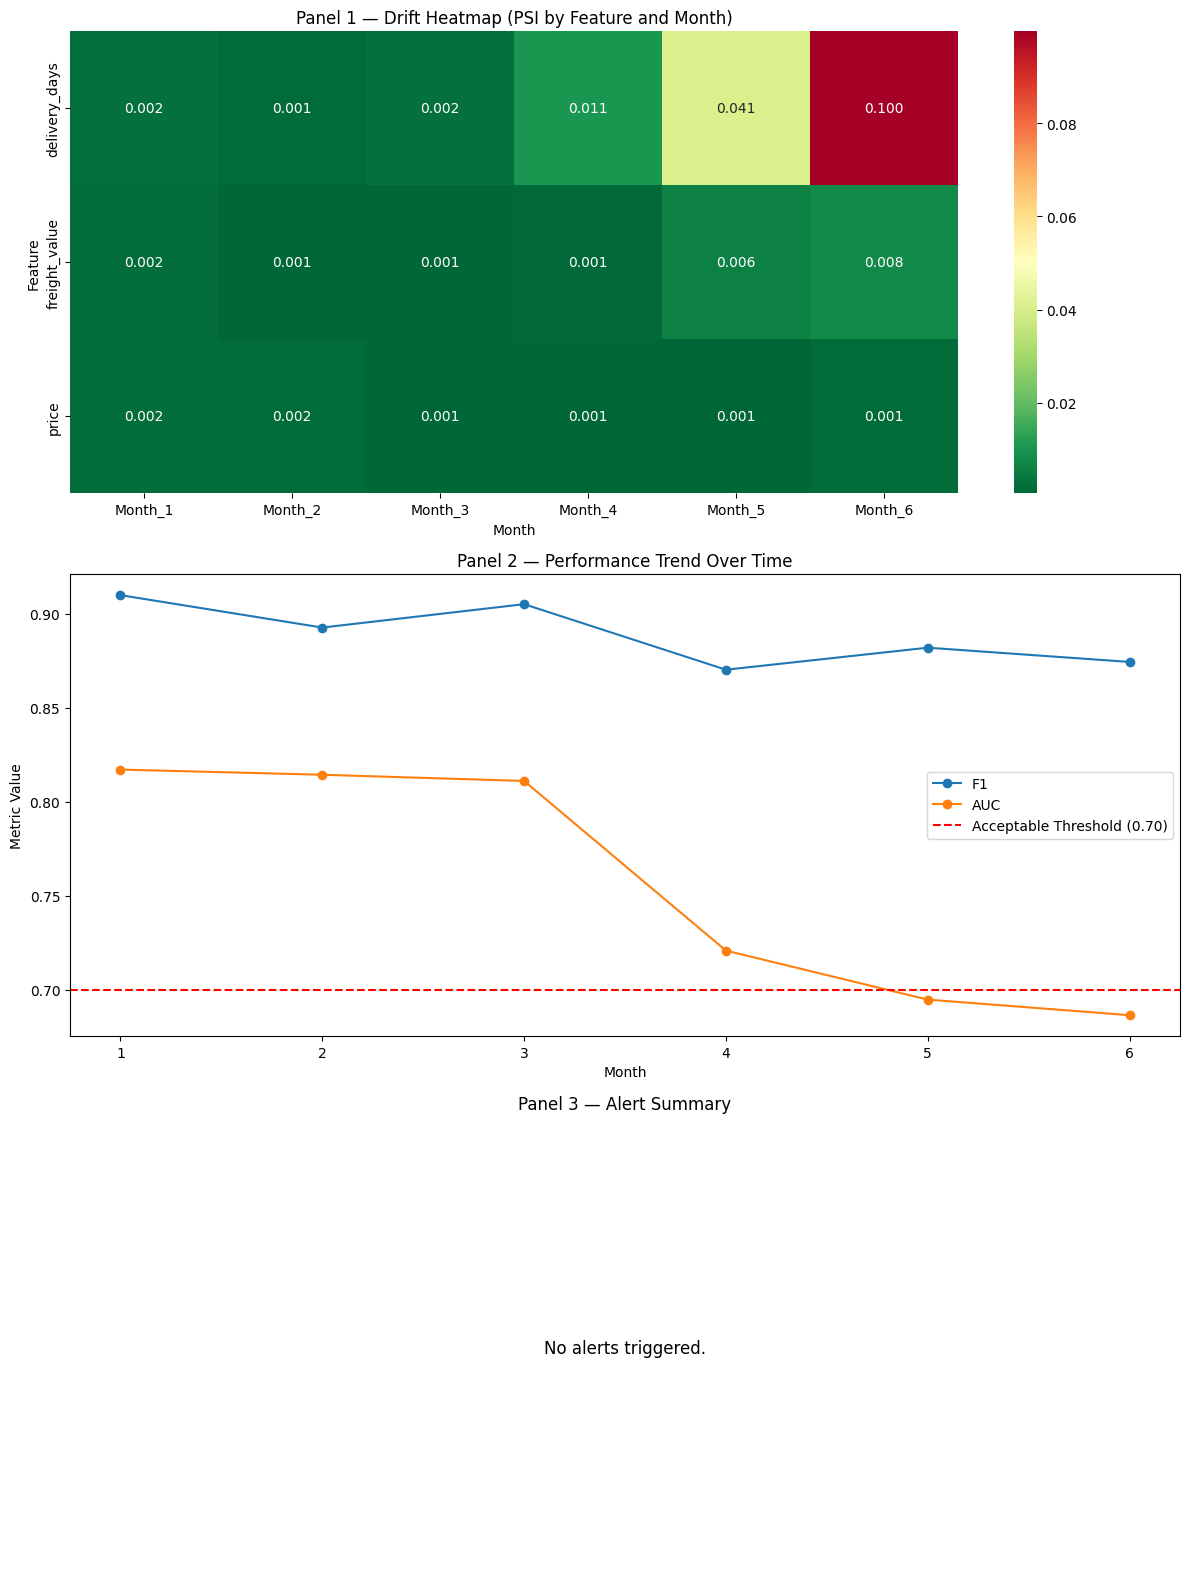

In [90]:
psi_heatmap_df = psi_df.set_index("Feature")

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Panel 1: PSI heatmap
sns.heatmap(
    psi_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    ax=axes[0]
)
axes[0].set_title("Panel 1 — Drift Heatmap (PSI by Feature and Month)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Feature")

# Panel 2: Performance trend
axes[1].plot(monthly_metrics_df["Month"], monthly_metrics_df["F1"], marker="o", label="F1")
axes[1].plot(monthly_metrics_df["Month"], monthly_metrics_df["AUC"], marker="o", label="AUC")
axes[1].axhline(y=0.70, linestyle="--", color="red", label="Acceptable Threshold (0.70)")
axes[1].set_title("Panel 2 — Performance Trend Over Time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Metric Value")
axes[1].legend()

# Panel 3: Alert summary table
axes[2].axis("off")

if len(alerts_df) > 0:
    table_df = alerts_df.copy().head(12)
    table = axes[2].table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    axes[2].set_title("Panel 3 — Alert Summary")
else:
    axes[2].text(0.5, 0.5, "No alerts triggered.", ha="center", va="center", fontsize=12)
    axes[2].set_title("Panel 3 — Alert Summary")

plt.tight_layout()
plt.show()

## Recommendation

Based on the monitoring results, the model should be retrained once both drift and performance deterioration become meaningful rather than waiting for the system to fail completely. In this analysis, PSI values that move into the moderate range (0.1–0.2) should trigger investigation, while PSI values above 0.2 should trigger action. I would also retrain if the model’s F1 or AUC drops by around 10% or more relative to the stable baseline, since that would indicate a practically meaningful decline in prediction quality.

The most likely retraining point in this simulation is during the later drift months, when delivery times, freight costs, and product mix have shifted enough to change the data distribution and degrade performance. At that stage, retraining should use more recent production data that reflects the updated delivery environment, shipping costs, and category mix rather than relying only on older historical patterns.

More broadly, the monitoring results show why ongoing model governance matters. Even a model that performs well at deployment can become less reliable as customer behavior, operations, and market conditions evolve. A retraining policy based on both PSI thresholds and performance drop is therefore more robust than relying on either signal alone.

# Part 2 — Experiment Tracking with MLflow

In this section, I use MLflow to log multiple model runs for the Olist customer satisfaction problem. The goal is to track parameters, metrics, and artifacts so that results are reproducible and comparable.

For HW4, I log two runs:
1. A Random Forest model
2. A Gradient Boosting model

For each run, I record:
- model type and key hyperparameters
- accuracy, precision, recall, F1, and ROC-AUC
- the trained model artifact

In [91]:
!pip install -q mlflow==2.19.0 joblib scikit-learn pandas numpy

In [92]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [93]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"
MLFLOW_DIR = "/content/drive/MyDrive/HW4_MLflow"

os.makedirs(MLFLOW_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MLFLOW_DIR:", MLFLOW_DIR)

DATA_DIR: /content/drive/MyDrive/Colab Notebooks/
MLFLOW_DIR: /content/drive/MyDrive/HW4_MLflow


## Load the Olist data and rebuild the deployable feature set

To keep the experiment tracking consistent with the deployed API, I rebuild the same structured Olist feature set used for the HW4 model.

In [94]:
files = {
    "orders_df": "olist_orders_dataset.csv.zip",
    "order_items_df": "olist_order_items_dataset.csv.zip",
    "order_payments_df": "olist_order_payments_dataset.csv.zip",
    "order_reviews_df": "olist_order_reviews_dataset.csv.zip",
    "customers_df": "olist_customers_dataset.csv.zip",
    "products_df": "olist_products_dataset.csv.zip",
    "sellers_df": "olist_sellers_dataset.csv",
    "category_translation_df": "product_category_name_translation.csv"
}

def load_any_csv(path):
    if path.endswith(".zip"):
        return pd.read_csv(path, compression="zip")
    return pd.read_csv(path)

tables = {name: load_any_csv(DATA_DIR + fname) for name, fname in files.items()}

orders_df = tables["orders_df"]
order_items_df = tables["order_items_df"]
order_payments_df = tables["order_payments_df"]
order_reviews_df = tables["order_reviews_df"]
products_df = tables["products_df"]
sellers_df = tables["sellers_df"]
category_translation_df = tables["category_translation_df"]

print("Loaded source tables.")

Loaded source tables.


In [95]:
products_en = products_df.copy()

if "product_category" not in products_en.columns:
    products_en = products_en.merge(
        category_translation_df,
        on="product_category_name",
        how="left"
    )
    products_en = products_en.rename(
        columns={"product_category_name_english": "product_category"}
    )

df = orders_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

df = df[df["review_score"].notna()].copy()
df["is_positive_review"] = (df["review_score"] >= 4).astype(int)

order_items_agg = (
    order_items_df.groupby("order_id")
    .agg(
        price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

payments_agg = (
    order_payments_df.groupby("order_id")
    .agg(
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

df = df.merge(order_items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")
df = df.merge(
    products_en[["product_id", "product_category"]],
    on="product_id",
    how="left"
)
df = df.merge(
    sellers_df[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"], errors="coerce")
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"], errors="coerce")

df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_vs_estimated"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "price",
    "freight_value",
    "product_category",
    "seller_state",
    "payment_type"
]

target_col = "is_positive_review"

df_model = df[feature_cols + [target_col]].dropna().copy()
print("Modeling shape:", df_model.shape)
df_model.head()

Modeling shape: (94981, 8)


,delivery_days,delivery_vs_estimated,price,freight_value,product_category,seller_state,payment_type,is_positive_review
0,8.0,-8.0,29.99,8.72,housewares,SP,credit_card,1
1,13.0,-6.0,118.70,22.76,perfumery,SP,boleto,1
2,9.0,-18.0,159.90,19.22,auto,SP,credit_card,1
3,13.0,-13.0,45.00,27.20,pet_shop,MG,credit_card,1
4,2.0,-10.0,19.90,8.72,stationery,SP,credit_card,1


In [96]:
X = df_model[feature_cols].copy()
y = df_model[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ["delivery_days", "delivery_vs_estimated", "price", "freight_value"]
categorical_features = ["product_category", "seller_state", "payment_type"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (75984, 7)
Test shape: (18997, 7)


## Set up MLflow

The HW4 instructions require an experiment named `olist-satisfaction`. I store the MLflow tracking files in Google Drive so the outputs persist across sessions.

In [97]:
mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")
mlflow.set_experiment("olist-satisfaction")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment set to: olist-satisfaction")

Tracking URI: file:///content/drive/MyDrive/HW4_MLflow
Experiment set to: olist-satisfaction


In [98]:
def evaluate_model(model_pipeline, X_test, y_test):
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

## Run 1 — Random Forest

In [99]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="random_forest_run"):
    rf_pipeline.fit(X_train, y_train)
    rf_metrics = evaluate_model(rf_pipeline, X_test, y_test)

    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("random_state", 42)

    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.sklearn.log_model(
        sk_model=rf_pipeline,
        artifact_path="model",
        registered_model_name="olist-satisfaction-model"
    )

rf_metrics

2026/04/17 18:58:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'olist-satisfaction-model' already exists. Creating a new version of this model...
Created version '3' of model 'olist-satisfaction-model'.


{'accuracy': 0.8228667684371217,
 'precision': 0.8239126802918082,
 'recall': 0.9864648619815976,
 'f1': 0.8978910635715369,
 'roc_auc': np.float64(0.6869918989948848)}

## Run 2 — Gradient Boosting

In [100]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        random_state=42
    ))
])

with mlflow.start_run(run_name="gradient_boosting_run"):
    gb_pipeline.fit(X_train, y_train)
    gb_metrics = evaluate_model(gb_pipeline, X_test, y_test)

    mlflow.log_param("model_type", "GradientBoostingClassifier")
    mlflow.log_param("n_estimators", 150)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("random_state", 42)

    for metric_name, metric_value in gb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.sklearn.log_model(
        sk_model=gb_pipeline,
        artifact_path="model",
        registered_model_name="olist-satisfaction-model"
    )

gb_metrics

2026/04/17 18:58:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'olist-satisfaction-model' already exists. Creating a new version of this model...
Created version '4' of model 'olist-satisfaction-model'.


{'accuracy': 0.8230246881086487,
 'precision': 0.8236177550339303,
 'recall': 0.9872649686624884,
 'f1': 0.8980470645317807,
 'roc_auc': np.float64(0.6849909903799459)}

## Compare the two runs

In [101]:
mlflow_summary = pd.DataFrame([
    {
        "Run": "Random Forest",
        "Accuracy": rf_metrics["accuracy"],
        "Precision": rf_metrics["precision"],
        "Recall": rf_metrics["recall"],
        "F1": rf_metrics["f1"],
        "ROC_AUC": rf_metrics["roc_auc"]
    },
    {
        "Run": "Gradient Boosting",
        "Accuracy": gb_metrics["accuracy"],
        "Precision": gb_metrics["precision"],
        "Recall": gb_metrics["recall"],
        "F1": gb_metrics["f1"],
        "ROC_AUC": gb_metrics["roc_auc"]
    }
])

mlflow_summary

,Run,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.822867,0.823913,0.986465,0.897891,0.686992
1,Gradient Boosting,0.823025,0.823618,0.987265,0.898047,0.684991


## Determine the best run

In [102]:
best_model_name = (
    "Random Forest"
    if rf_metrics["roc_auc"] >= gb_metrics["roc_auc"]
    else "Gradient Boosting"
)

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Random Forest


## Next step outside the notebook

After running these cells, start the MLflow UI locally and take screenshots of:
1. the Experiments page showing both runs
2. the Model Registry page showing the registered model

Then move the best model version to the **Production** stage, as required by HW4.

### MLflow notes for HW4

This section satisfies the core tracking requirement because it:
- creates the `olist-satisfaction` experiment
- logs at least two runs
- records parameters and metrics
- logs the trained model artifact
- registers the model in the MLflow Model Registry